# BiSeNet para Segmentação Semântica
Treinar e testar BiSeNet em PyTorch usando Cityscapes, com configurações similares a Fast-SCNN e ENet.

## 1. Importação das Bibliotecas


In [75]:
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import numpy as np
import os
import glob
import torch
import matplotlib.pyplot as plt
import sys
import random

## 2. Definição da Arquitetura BiSeNet
BiSeNet, configurando o número de classes para Cityscapes (19 classes).

In [76]:
if not os.path.exists('BiSeNet'):
    !git clone https://github.com/CoinCheung/BiSeNet.git

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

sys.path.append('./BiSeNet/lib/models')
from bisenetv2 import BiSeNetV2

num_classes = 19
model = BiSeNetV2(n_classes=num_classes)
model.to(device)
print('BiSeNetV2 oficial inicializado!')

BiSeNetV2 oficial inicializado!


In [77]:
# Alternativas de importação para BiSeNetV2
try:
    sys.path.append('./BiSeNet/lib/models')
    from bisenetv2 import BiSeNetV2
    print('Importação via BiSeNet/lib/models bem-sucedida!')
except ModuleNotFoundError:
    try:
        sys.path.append('./BiSeNet/lib')
        from models.bisenetv2 import BiSeNetV2
        print('Importação via BiSeNet/lib bem-sucedida!')
    except ModuleNotFoundError:
        try:
            sys.path.append('./BiSeNet')
            from lib.models.bisenetv2 import BiSeNetV2
            print('Importação via BiSeNet bem-sucedida!')
        except ModuleNotFoundError:
            print('Não foi possível importar BiSeNetV2. Verifique o caminho.')

num_classes = 19
model = BiSeNetV2(n_classes=num_classes)
model.to(device)
print('BiSeNetV2 oficial inicializado!')

Importação via BiSeNet/lib/models bem-sucedida!
BiSeNetV2 oficial inicializado!


In [78]:
# Implementação simplificada do BiSeNet (PyTorch)
class ConvBNReLU(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, stride, padding):
        super().__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding, bias=False)
        self.bn = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
    def forward(self, x):
        return self.relu(self.bn(self.conv(x)))

class BiSeNet(nn.Module):
    def __init__(self, num_classes=19):
        super().__init__()
        # Context Path (simplificado)
        self.context = nn.Sequential(
            ConvBNReLU(3, 32, 3, 2, 1),
            ConvBNReLU(32, 64, 3, 2, 1),
            ConvBNReLU(64, 128, 3, 2, 1),
            nn.AdaptiveAvgPool2d((1, 1))
        )
        # Spatial Path (simplificado)
        self.spatial = nn.Sequential(
            ConvBNReLU(3, 16, 3, 2, 1),
            ConvBNReLU(16, 32, 3, 2, 1),
            ConvBNReLU(32, 64, 3, 2, 1)
        )
        # Fusion & Classifier
        self.fusion = nn.Sequential(
            nn.Conv2d(192, 128, 1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True)
        )
        self.classifier = nn.Conv2d(128, num_classes, 1)
    def forward(self, x):
        spatial_out = self.spatial(x)
        context_out = self.context(x)
        context_out = context_out.expand(-1, -1, spatial_out.shape[2], spatial_out.shape[3])
        fusion = torch.cat([spatial_out, context_out], dim=1)
        fusion = self.fusion(fusion)
        out = self.classifier(fusion)
        out = nn.functional.interpolate(out, scale_factor=8, mode='bilinear', align_corners=False)
        return out

## 3. Preparação do Dataset Cityscapes
classe Dataset para carregar imagens e máscaras do Cityscapes, convertendo as máscaras para trainIDs e redimensionando para (256, 512).

In [79]:
# Dataset Cityscapes para BiSeNet
class CityscapesDatasetBiSeNet(Dataset):
    def __init__(self, cityscapes_root, split='train', img_height=256, img_width=512, max_samples=2000):
        self.cityscapes_root = cityscapes_root
        self.split = split
        self.img_height = img_height
        self.img_width = img_width
        self.img_dir = os.path.join(cityscapes_root, 'leftImg8bit', split)
        self.gtfine_dir = os.path.join(cityscapes_root, 'gtFine', split)
        self.images = []
        self.annotations = []
        count = 0
        for city in sorted(os.listdir(self.img_dir)):
            city_img_dir = os.path.join(self.img_dir, city)
            city_gtfine_dir = os.path.join(self.gtfine_dir, city)
            if not os.path.isdir(city_img_dir):
                continue
            for img_file in sorted(os.listdir(city_img_dir)):
                if img_file.endswith('_leftImg8bit.png'):
                    img_path = os.path.join(city_img_dir, img_file)
                    base_name = img_file.replace('_leftImg8bit.png', '')
                    gtfine_file = f'{base_name}_gtFine_color.png'
                    gtfine_path = os.path.join(city_gtfine_dir, gtfine_file)
                    if os.path.exists(gtfine_path):
                        self.images.append(img_path)
                        self.annotations.append(gtfine_path)
                        count += 1
                        if max_samples and count >= max_samples:
                            break
            if max_samples and count >= max_samples:
                break
        print(f'Dataset {split}: {len(self.images)} imagens encontradas')
        self.cityscapes_color_to_train = {
            (128, 64, 128): 0, (244, 35, 232): 1, (70, 70, 70): 2, (102, 102, 156): 3,
            (190, 153, 153): 4, (153, 153, 153): 5, (250, 170, 30): 6, (220, 220, 0): 7,
            (107, 142, 35): 8, (152, 251, 152): 9, (70, 130, 180): 10, (220, 20, 60): 11,
            (255, 0, 0): 12, (0, 0, 142): 13, (0, 0, 70): 14, (0, 60, 100): 15,
            (0, 80, 100): 16, (0, 0, 230): 17, (119, 11, 32): 18
        }
    def __len__(self):
        return len(self.images)
    def _rgb_to_trainid(self, mask_rgb):
        # Ensure mask_rgb has shape (H, W, 3) before reshaping
        if mask_rgb.ndim != 3 or mask_rgb.shape[2] != 3:
            raise ValueError(f"mask_rgb shape is {mask_rgb.shape}, expected (H, W, 3)")
        h, w = mask_rgb.shape[:2]
        trainid_mask = np.full((h, w), 255, dtype=np.uint8)
        mask_flat = mask_rgb.reshape(-1, 3)
        for color, train_id in self.cityscapes_color_to_train.items():
            matches = np.all(mask_flat == color, axis=1)
            trainid_mask.flat[matches] = train_id
        return trainid_mask
    def __getitem__(self, idx):
        img = Image.open(self.images[idx]).convert('RGB')
        img = img.resize((self.img_width, self.img_height))
        img = np.array(img, dtype=np.float32) / 255.0
        mask = Image.open(self.annotations[idx])
        mask = mask.resize((self.img_width, self.img_height), Image.NEAREST)
        mask_rgb = np.array(mask, dtype=np.uint8)
        # If mask has 4 channels (RGBA), convert to RGB
        if mask_rgb.ndim == 3 and mask_rgb.shape[2] == 4:
            mask_rgb = mask_rgb[:, :, :3]
        if mask_rgb.ndim != 3 or mask_rgb.shape[2] != 3:
            print(f"Erro: máscara {self.annotations[idx]} tem shape {mask_rgb.shape}")
        trainid_mask = self._rgb_to_trainid(mask_rgb)
        img_tensor = torch.from_numpy(img).permute(2, 0, 1).float()
        mask_tensor = torch.from_numpy(trainid_mask).long()
        return img_tensor, mask_tensor

## 4. Inicialização do Modelo BiSeNet
BiSeNet para GPU se disponível

In [80]:
# Inicialização do modelo BiSeNet
num_classes = 19
cityscapes_root = r'd:\Documentos\Git\edge-segmentation-lab\city'
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = BiSeNet(num_classes=num_classes).to(device)
print(f'Usando dispositivo: {device}')
if device.type == 'cuda':
    print('Nome da GPU:', torch.cuda.get_device_name(0))
    print('Memória total da GPU (MB):', torch.cuda.get_device_properties(0).total_memory // (1024*1024))
    print('Memória alocada (MB):', torch.cuda.memory_allocated(0) // (1024*1024))
else:
    print('No GPU found, usando CPU')
print(f'Modelo BiSeNet criado e movido para {device}')
print(f'Número de parâmetros: {sum(p.numel() for p in model.parameters())/1e6:.2f}M')

Usando dispositivo: cuda
Nome da GPU: NVIDIA GeForce GTX 1660 SUPER
Memória total da GPU (MB): 6143
Memória alocada (MB): 61
Modelo BiSeNet criado e movido para cuda
Número de parâmetros: 0.14M


## 5. Configuração do Treinamento


In [81]:
# Configuração do DataLoader e treinamento
train_dataset = CityscapesDatasetBiSeNet(cityscapes_root, split='train', img_height=256, img_width=512, max_samples=2300)
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, num_workers=0, pin_memory=True)

criterion = nn.CrossEntropyLoss(ignore_index=255)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

num_epochs = 20



print(f'Treinando por {num_epochs} épocas com {len(train_dataset)} imagens...')

Dataset train: 2300 imagens encontradas
Treinando por 20 épocas com 2300 imagens...


## 6. Loop de Treinamento

In [82]:
# Loop de treinamento BiSeNet
best_loss = float('inf')
for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    for imgs, masks in train_loader:
        imgs, masks = imgs.to(device), masks.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    avg_train_loss = train_loss / len(train_loader)
    scheduler.step(avg_train_loss)
    if avg_train_loss < best_loss:
        best_loss = avg_train_loss
        torch.save(model.state_dict(), 'bisenet_best.pth')
        print(f'Epoca {epoch+1}/{num_epochs} | Loss: {avg_train_loss:.4f} ⭐')
    else:
        print(f'Epoca {epoch+1}/{num_epochs} | Loss: {avg_train_loss:.4f}')

Epoca 1/20 | Loss: 0.9884 ⭐
Epoca 2/20 | Loss: 0.8211 ⭐
Epoca 2/20 | Loss: 0.8211 ⭐
Epoca 3/20 | Loss: 0.7750 ⭐
Epoca 3/20 | Loss: 0.7750 ⭐
Epoca 4/20 | Loss: 0.7424 ⭐
Epoca 4/20 | Loss: 0.7424 ⭐
Epoca 5/20 | Loss: 0.7180 ⭐
Epoca 5/20 | Loss: 0.7180 ⭐
Epoca 6/20 | Loss: 0.6958 ⭐
Epoca 6/20 | Loss: 0.6958 ⭐
Epoca 7/20 | Loss: 0.6808 ⭐
Epoca 7/20 | Loss: 0.6808 ⭐
Epoca 8/20 | Loss: 0.6711 ⭐
Epoca 8/20 | Loss: 0.6711 ⭐
Epoca 9/20 | Loss: 0.6564 ⭐
Epoca 9/20 | Loss: 0.6564 ⭐
Epoca 10/20 | Loss: 0.6503 ⭐
Epoca 10/20 | Loss: 0.6503 ⭐
Epoca 11/20 | Loss: 0.6406 ⭐
Epoca 11/20 | Loss: 0.6406 ⭐
Epoca 12/20 | Loss: 0.6316 ⭐
Epoca 12/20 | Loss: 0.6316 ⭐
Epoca 13/20 | Loss: 0.6221 ⭐
Epoca 13/20 | Loss: 0.6221 ⭐
Epoca 14/20 | Loss: 0.6187 ⭐
Epoca 14/20 | Loss: 0.6187 ⭐
Epoca 15/20 | Loss: 0.6092 ⭐
Epoca 15/20 | Loss: 0.6092 ⭐
Epoca 16/20 | Loss: 0.6048 ⭐
Epoca 16/20 | Loss: 0.6048 ⭐
Epoca 17/20 | Loss: 0.5956 ⭐
Epoca 17/20 | Loss: 0.5956 ⭐
Epoca 18/20 | Loss: 0.5909 ⭐
Epoca 18/20 | Loss: 0.5909 ⭐
Ep

## 7. Salvar o Modelo Treinado


In [83]:
# Salvar modelo treinado
os.makedirs('models', exist_ok=True)
torch.save(model.state_dict(), os.path.join('models', 'bisenet_best.pth'))
print('Modelo treinado salvo em models/bisenet_best.pth')

Modelo treinado salvo em models/bisenet_best.pth


## 8. Inferência e Visualização em Imagens de Teste
Carrega uma imagem de teste, inferência com o modelo treinado, máscara predita e visualize lado a lado com a imagem original usando matplotlib.

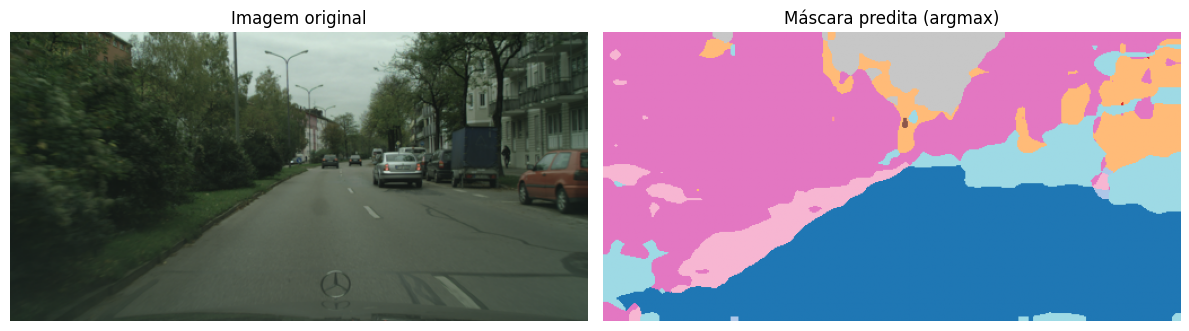

In [84]:
# Inferência e visualização em uma imagem de teste
img_path = r'D:\Documentos\Git\edge-segmentation-lab\city\leftImg8bit\test\munich\munich_000390_000019_leftImg8bit.png'
img = Image.open(img_path).convert('RGB')
img_resized = img.resize((512, 256))
img_np = np.array(img_resized, dtype=np.float32) / 255.0
img_tensor = torch.from_numpy(img_np).permute(2, 0, 1).unsqueeze(0).float().to(device)
model.eval()
with torch.no_grad():
    output = model(img_tensor)
    pred_mask = torch.argmax(output, dim=1).squeeze().cpu().numpy()
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.title('Imagem original')
plt.imshow(img_resized)
plt.axis('off')
plt.subplot(1,2,2)
plt.title('Máscara predita (argmax)')
plt.imshow(pred_mask, cmap='tab20')
plt.axis('off')
plt.tight_layout()
plt.show()

## 9. Avaliação Automática em Imagens de Munique
Avalia o modelo em 5 imagens de Munique, mostrando as predições coloridas e as imagens originais.

Arquivo: munich_000000_000019_leftImg8bit.png


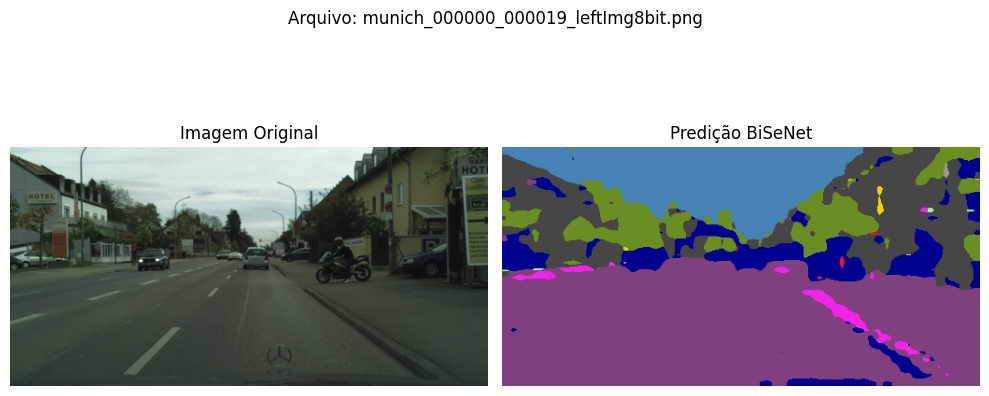

Arquivo: munich_000001_000019_leftImg8bit.png


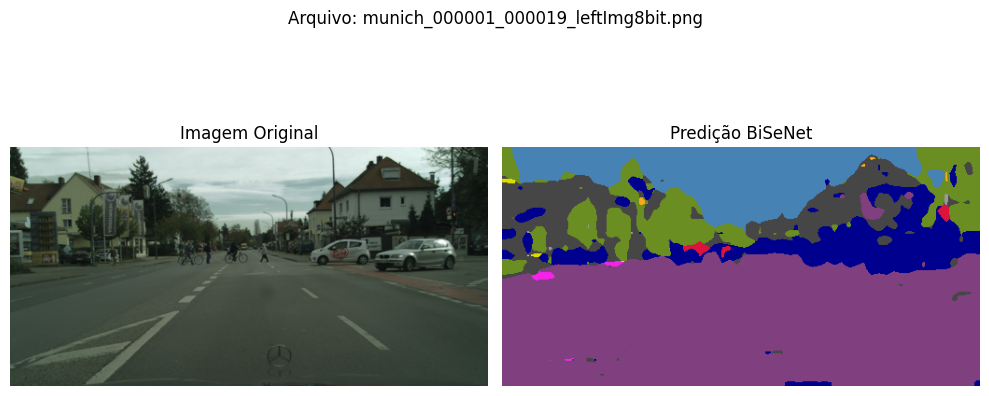

Arquivo: munich_000002_000019_leftImg8bit.png


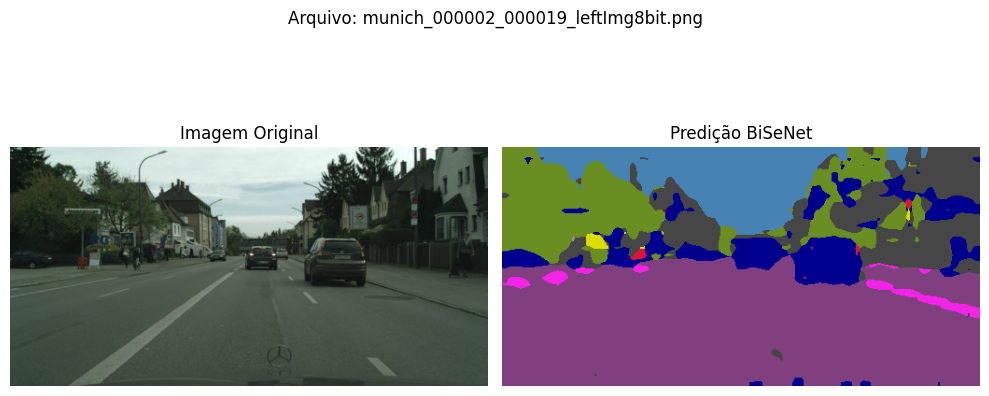

Arquivo: munich_000003_000019_leftImg8bit.png


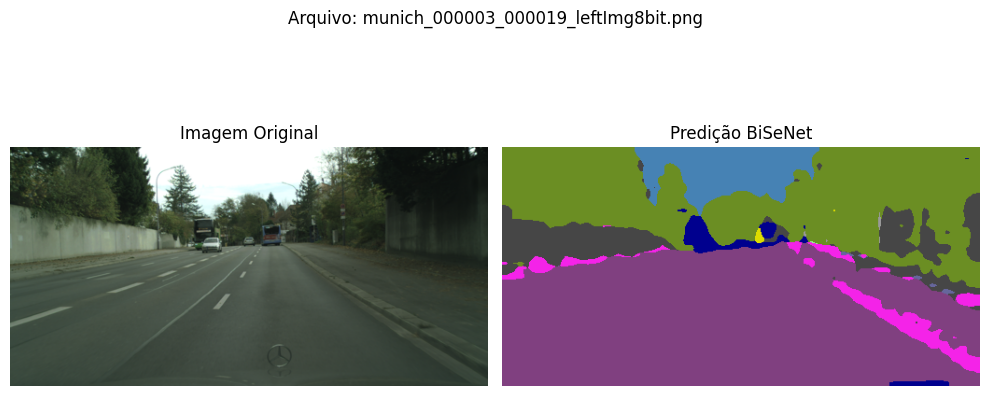

Arquivo: munich_000004_000019_leftImg8bit.png


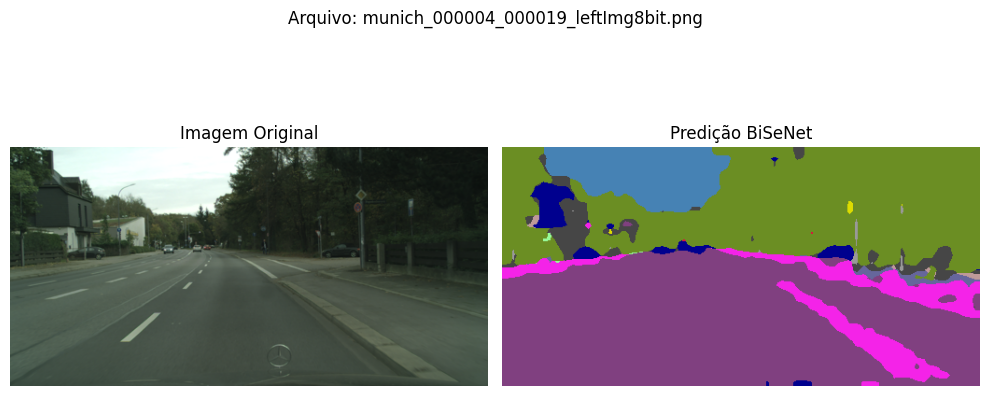

In [85]:
# Avaliação automática em 5 imagens fixas de Munique usando apenas predição do modelo
munich_dir = r'D:\Documentos\Git\edge-segmentation-lab\city\leftImg8bit\test\munich'
munich_imgs = sorted(glob.glob(os.path.join(munich_dir, '*_leftImg8bit.png')))[:5]

def decode_segmap(pred):
    # Função para colorir a máscara predita
    label_colors = np.array([
        [128, 64, 128], [244, 35, 232], [70, 70, 70], [102, 102, 156],
        [190, 153, 153], [153, 153, 153], [250, 170, 30], [220, 220, 0],
        [107, 142, 35], [152, 251, 152], [70, 130, 180], [220, 20, 60],
        [255, 0, 0], [0, 0, 142], [0, 0, 70], [0, 60, 100],
        [0, 80, 100], [0, 0, 230], [119, 11, 32], [0, 0, 0] # 19 classes
    ])
    r = np.zeros_like(pred).astype(np.uint8)
    g = np.zeros_like(pred).astype(np.uint8)
    b = np.zeros_like(pred).astype(np.uint8)
    for l in range(19):
        idx = pred == l
        r[idx] = label_colors[l, 0]
        g[idx] = label_colors[l, 1]
        b[idx] = label_colors[l, 2]
    rgb = np.stack([r, g, b], axis=2)
    return rgb

num_classes = 19
model.eval()
with torch.no_grad():
    for img_path in munich_imgs:
        print(f'Arquivo: {os.path.basename(img_path)}')
        img = Image.open(img_path).convert('RGB')
        img_resized = img.resize((512, 256))
        img_np = np.array(img_resized, dtype=np.float32) / 255.0
        img_tensor = torch.from_numpy(img_np).permute(2, 0, 1).unsqueeze(0).float().to(device)
        output = model(img_tensor)
        pred = torch.argmax(output, dim=1).squeeze().cpu().numpy()
        color_mask = decode_segmap(pred)
        plt.figure(figsize=(10,5))
        plt.subplot(1,2,1)
        plt.imshow(img_resized)
        plt.title('Imagem Original')
        plt.axis('off')
        plt.subplot(1,2,2)
        plt.imshow(color_mask)
        plt.title('Predição BiSeNet')
        plt.axis('off')
        plt.suptitle(f'Arquivo: {os.path.basename(img_path)}')
        plt.tight_layout()
        plt.show()